# Part III — Paper Reproduction: Indoor Robot Path Navigation with Q-Learning

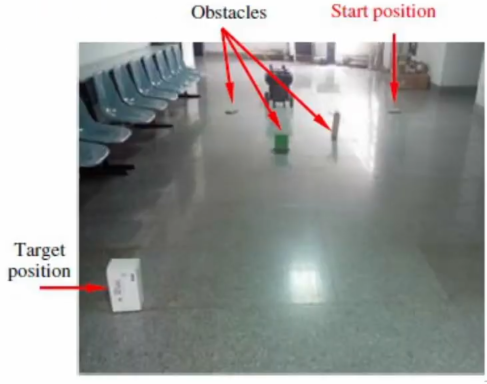



This section reproduces, in Python, the indoor robot path-navigation problem described in:

**Huang, L., He, D., Zhang, Z., & Zhang, P. (2016). _Path Navigation For Indoor Robot With Q-Learning_. Intelligent Automation & Soft Computing, 22(2), 317–323.**  
DOI: `10.1080/10798587.2015.1095485`

The goal is to convert the paper/lecture-slide example into a portfolio-quality computational experiment.

The section includes:

- the problem definition;
- offline and online navigation stages;
- state, action, reward, and Q-learning formulation;
- the robot-motion architecture drawn with Python;
- the $\epsilon$-greedy flowchart drawn with Python;
- the $30\times30$ topological map;
- the Q-learning training mechanism;
- the episode-steps convergence plot;
- explored paths and the learned/best path;
- Q-values at selected states;
- a 3D state-action Q-value visualization;
- the smaller $5\times9$ real-robot map;
- the real-robot workflow drawn with Python;
- an explanation of the slide that mentions **multi-agent Q-learning**.

## Important reproduction note

Several numerical details are stated explicitly in the paper, but some geometric details are only visible in the figures.

The paper explicitly specifies:

$$
\alpha=0.1,\qquad
\gamma=0.95,\qquad
\epsilon=0.1,
$$

with:

- $200$ learning episodes;
- at most $2000$ steps per episode;
- a $30\times30$ map;
- $900$ states;
- four actions;
- start position $P(0,3)$;
- target position $P(29,24)$.

The exact obstacle coordinates and a numerical value for the safe-distance parameter $d_s$ are not listed in the text available with the paper. Therefore, the code below **reconstructs the obstacle coordinates from the figure** and uses one grid cell as the safe-distance threshold. Those are reproduction assumptions, not claims that the paper explicitly listed those numbers.

Because Q-learning is stochastic and some implementation details are not fully specified, our numerical learning curve does not have to match the published curve point-for-point. The notebook reproduces the stated problem, parameter settings, update rule, and graph types.

## 26. Problem Description

The paper studies a **single indoor mobile robot** that must learn a safe, short route from a known starting position to a known target while avoiding obstacles.

The robot initially has limited information. It knows:

- its start/current position;
- the target coordinates.

It uses local sensing for obstacle avoidance and learns from interaction with the environment.

The computational problem is:

$$
\boxed{
\text{Start} \rightarrow
\text{Explore the grid} \rightarrow
\text{Avoid obstacles} \rightarrow
\text{Learn Q-values} \rightarrow
\text{Reach target using a short path}
}
$$

A successful trip from the start to the target is one **episode**. After an episode, the robot is returned to the start and learning begins again.

### Offline and online stages

The navigation architecture has two stages.

**Offline / PC simulation**

1. Model the environment.
2. Train the Q-learning agent.
3. Obtain the Q-table and a good path.

**Online / real robot**

1. Transfer the learned information to the robot.
2. Initialize the robot with the learned Q-values/path.
3. Navigate the physical corridor.
4. Use sensors to react to local obstacles.

The paper therefore does not train the physical robot entirely from scratch in the corridor. The PC simulation provides an initialized navigation solution that can then be used by the real robot.

## 27. Q-Learning Formulation Used in the Paper

The state is a discrete grid position.

For the $30\times30$ simulation:

$$
|\mathcal S|=30\times30=900.
$$

The four actions are:

$$
\mathcal A=
\{\text{Up},\text{Down},\text{Left},\text{Right}\}.
$$

The Q-learning update is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_a Q(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

The paper uses:

$$
\alpha=0.1,\qquad
\gamma=0.95,\qquad
\epsilon=0.1.
$$

The standard $\epsilon$-greedy interpretation stated in the paper is:

$$
A_t=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon,\\
\arg\max_a Q(S_t,a), & \text{with probability }1-\epsilon.
\end{cases}
$$

One sentence in the paper/slide describes the effect of increasing or decreasing $\epsilon$ in the opposite direction. That conflicts with the probability definition above. The implementation below follows the explicit probability rule: $\epsilon=0.1$ means 10% exploratory action selection.

## 28. Reward and Obstacle-Avoidance Strategy

The paper defines a piecewise immediate reward:

$$
r=
\begin{cases}
-2, & d_{\min}<d_s \text{ and a collision occurs},\\
-0.2, & d_{\min}=d_s,\\
0, & \text{otherwise},\\
+2, & d_o<d_s \text{ / target reached}.
\end{cases}
$$

where:

- $d_{\min}$ is the minimum robot-to-obstacle distance;
- $d_s$ is the minimum safe distance;
- $d_o$ is the robot-to-target distance.

The idea is simple:

- collision $\rightarrow$ strong punishment;
- dangerously close to an obstacle $\rightarrow$ small punishment;
- ordinary motion $\rightarrow$ zero immediate reward;
- target $\rightarrow$ strong positive reward.

The paper notes that reward design directly affects the speed and quality of learning.

## 29. Robot Motion Architecture — Coded Version

The slide separates the **PC simulation** and the **real robot platform**.

The following cell redraws that architecture with Matplotlib rather than inserting the lecture image.

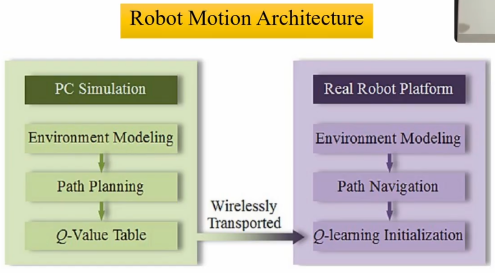

## 30. $\epsilon$-Greedy Policy

The robot alternates between exploitation and exploration.

With $\epsilon=0.1$:

- greedy action probability $\approx 0.9$;
- exploratory action probability $\approx 0.1$.

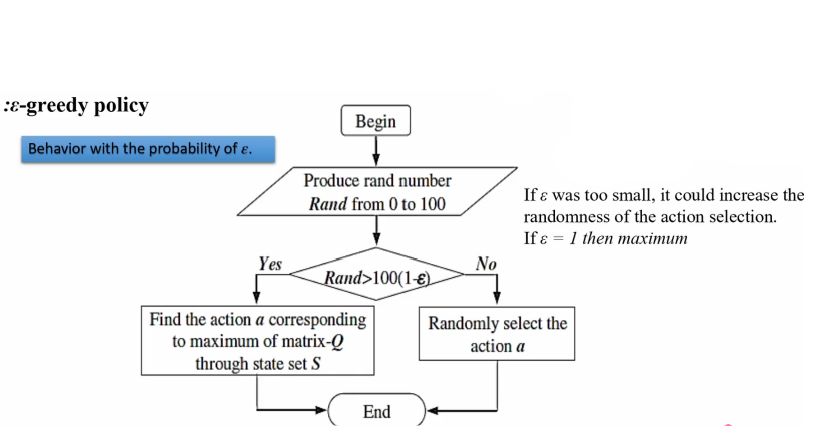

## 31. Reconstruct the $30\times30$ Topological Environment

The paper gives:

$$
P_{\text{start}}=(0,3)
$$

and

$$
P_{\text{goal}}=(29,24).
$$

The black obstacle cells below are reconstructed from the figure in the lecture material.

The shortest possible Manhattan distance between start and target is

$$
|29-0|+|24-3|=50
$$

moves, provided the obstacles do not force a detour. This agrees with the paper's reported shortest path of **50 steps**.

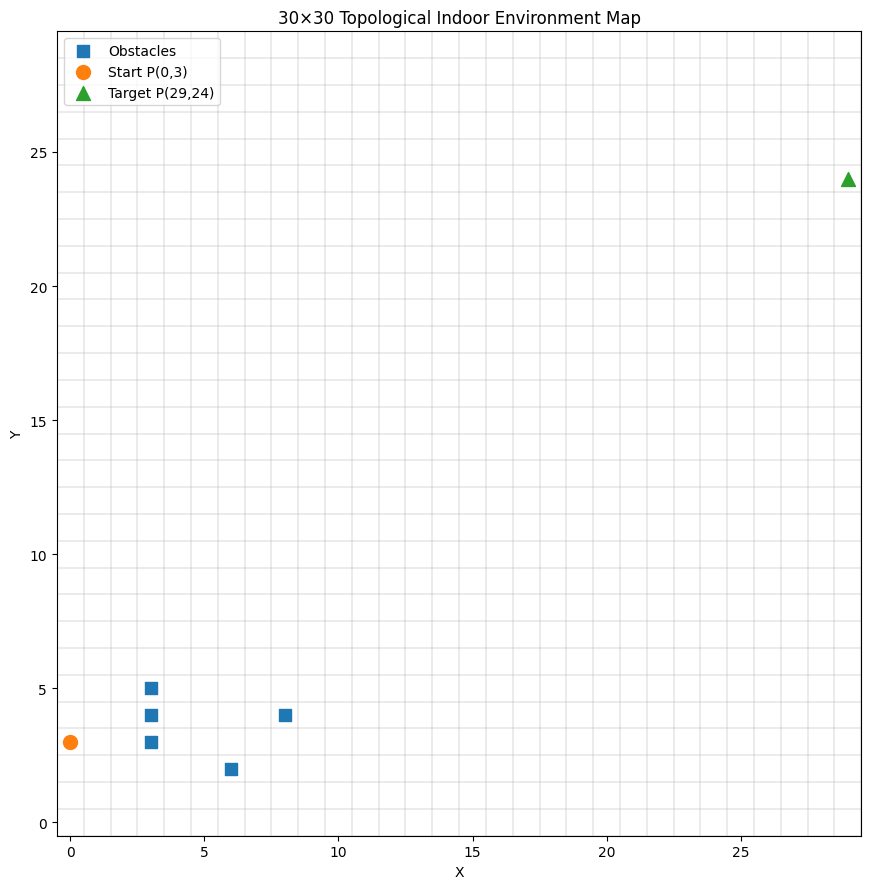

In [16]:
GRID_W = 30
GRID_H = 30

START = (0, 3)
GOAL = (29, 24)

# Reconstructed from the displayed topological-map figure.
OBSTACLES = {
    (3, 3), (3, 4), (3, 5),
    (6, 2),
    (8, 4)
}

def draw_grid_map(path=None, title="30×30 Topological Indoor Environment Map"):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(-0.5, GRID_H - 0.5)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(-0.5, GRID_W, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_H, 1), minor=True)
    ax.grid(which="minor", linewidth=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)

    ox = [p[0] for p in OBSTACLES]
    oy = [p[1] for p in OBSTACLES]
    ax.scatter(ox, oy, marker="s", s=70, label="Obstacles")
    ax.scatter(*START, s=100, label="Start P(0,3)")
    ax.scatter(*GOAL, s=100, marker="^", label="Target P(29,24)")

    if path is not None and len(path) > 1:
        px = [p[0] for p in path]
        py = [p[1] for p in path]
        ax.plot(px, py, linewidth=2.5, label="Path")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

draw_grid_map()

## 32. Q-Learning Mechanism

The paper's training logic is:

1. initialize the environment;
2. initialize the Q-table;
3. start an episode;
4. select an action using $\epsilon$-greedy;
5. execute the action;
6. observe the next state and reward;
7. update $Q(S_t,A_t)$;
8. stop the episode at the target or maximum step count;
9. repeat until the episode limit/convergence condition is reached.

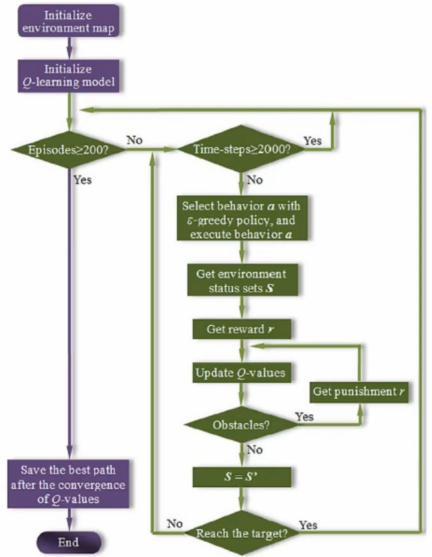

## 33. Python Environment for the Paper-Style Simulation

The implementation uses the paper's stated training parameters.

The safe-distance value $d_s$ is not numerically specified in the available paper text, so the grid reconstruction uses:

$$
d_s=1\text{ grid cell}.
$$

Attempting to move outside the map or into an obstacle is treated as a collision and leaves the robot in its current cell.

In [17]:
from math import dist

ALPHA_ROBOT = 0.1
GAMMA_ROBOT = 0.95
EPSILON_ROBOT = 0.1
EPISODES_ROBOT = 200
MAX_STEPS_ROBOT = 2000
SAFE_DISTANCE = 1.0

ACTION_NAMES_ROBOT = ["Up", "Down", "Left", "Right"]
ACTION_DELTAS = [(0, 1), (0, -1), (-1, 0), (1, 0)]

def state_index(pos):
    x, y = pos
    return y * GRID_W + x

def step_robot(pos, action):
    dx, dy = ACTION_DELTAS[action]
    candidate = (pos[0] + dx, pos[1] + dy)

    # Collision with boundary or obstacle.
    if (
        candidate[0] < 0 or candidate[0] >= GRID_W or
        candidate[1] < 0 or candidate[1] >= GRID_H or
        candidate in OBSTACLES
    ):
        return pos, -2.0, False

    # Target.
    if candidate == GOAL:
        return candidate, 2.0, True

    # Small punishment when one grid unit from an obstacle.
    if OBSTACLES:
        d_min = min(dist(candidate, obs) for obs in OBSTACLES)
        if np.isclose(d_min, SAFE_DISTANCE):
            return candidate, -0.2, False

    return candidate, 0.0, False

def epsilon_greedy_robot(q_table, pos, epsilon, rng):
    s = state_index(pos)
    if rng.random() < epsilon:
        return int(rng.integers(4))

    row = q_table[s]
    best = np.flatnonzero(row == np.max(row))
    return int(rng.choice(best))

## 34. Train Q-Learning with the Paper Settings

The next cell stores:

- number of steps per episode;
- total reward per episode;
- path taken in every episode;
- maximum Q-table change per episode.

These records will be used to recreate the plots shown in the paper/lecture.

In [18]:
def train_robot_q_learning(
    episodes=EPISODES_ROBOT,
    max_steps=MAX_STEPS_ROBOT,
    alpha=ALPHA_ROBOT,
    gamma=GAMMA_ROBOT,
    epsilon=EPSILON_ROBOT,
    seed=42
):
    rng = np.random.default_rng(seed)
    q = np.zeros((GRID_W * GRID_H, 4), dtype=float)

    steps_history = []
    reward_history = []
    delta_history = []
    episode_paths = []

    for episode in range(episodes):
        pos = START
        path = [pos]
        total_reward = 0.0
        q_before = q.copy()

        for step in range(1, max_steps + 1):
            action = epsilon_greedy_robot(q, pos, epsilon, rng)
            next_pos, reward, done = step_robot(pos, action)

            s = state_index(pos)
            s_next = state_index(next_pos)

            target = reward if done else reward + gamma * np.max(q[s_next])
            q[s, action] += alpha * (target - q[s, action])

            pos = next_pos
            path.append(pos)
            total_reward += reward

            if done:
                break

        steps_history.append(step)
        reward_history.append(total_reward)
        delta_history.append(np.max(np.abs(q - q_before)))
        episode_paths.append(path)

    return (
        q,
        np.array(steps_history),
        np.array(reward_history),
        np.array(delta_history),
        episode_paths
    )

q_robot, robot_steps, robot_rewards, robot_delta, robot_paths = train_robot_q_learning()

print("Training episodes:", len(robot_steps))
print("Best episode length:", robot_steps.min())
print("Final 10 episode lengths:", robot_steps[-10:])
print("Mean of final 20 episode lengths:", robot_steps[-20:].mean())

Training episodes: 200
Best episode length: 67
Final 10 episode lengths: [190 290 316 429 180 334  67 448 128 727]
Mean of final 20 episode lengths: 334.25


## 35. Convergence Plot: Steps vs. Episodes

This reproduces the graph type shown in the slide.

The paper reports a rapid fall in episode length and a shortest path of about 50 steps. Because the exact obstacle coordinates, safe-distance threshold, tie-breaking logic, and implementation details are not fully reported, this reconstruction should be interpreted as a **computational reproduction**, not a claim of point-for-point replication.

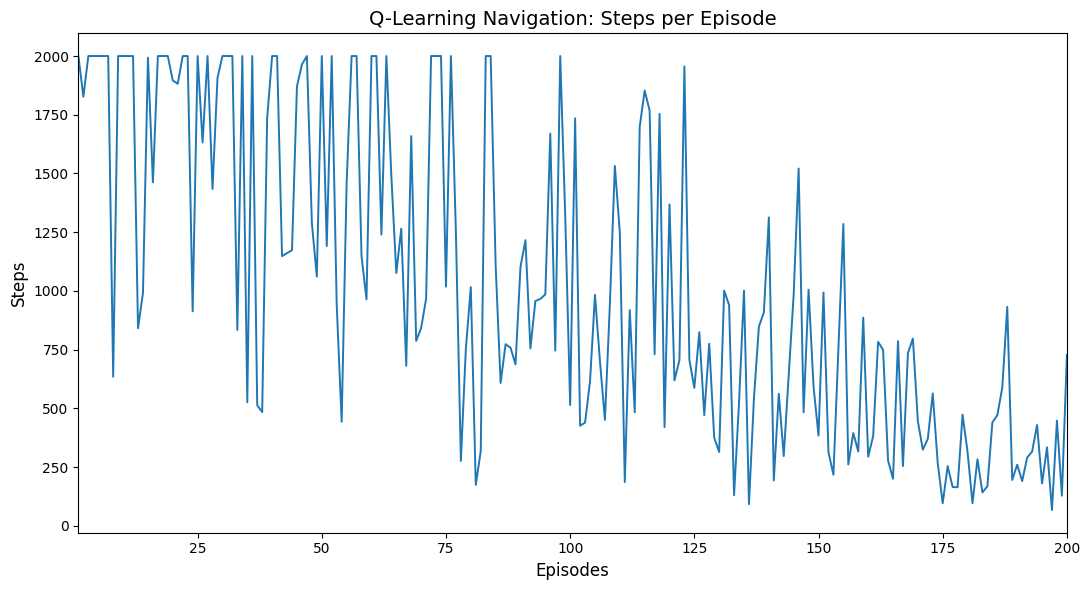

In [19]:
plt.figure(figsize=(11, 6))
plt.plot(np.arange(1, EPISODES_ROBOT + 1), robot_steps, linewidth=1.4)
plt.xlabel("Episodes", fontsize=12)
plt.ylabel("Steps", fontsize=12)
plt.title("Q-Learning Navigation: Steps per Episode", fontsize=14)
plt.xlim(1, EPISODES_ROBOT)
plt.tight_layout()
plt.show()

## 36. Explored Paths and the Best Learned Episode

The lecture figure overlays several learned/explored trajectories and emphasizes the best path.

The next graph draws a sample of episode paths lightly and the best observed episode more strongly.

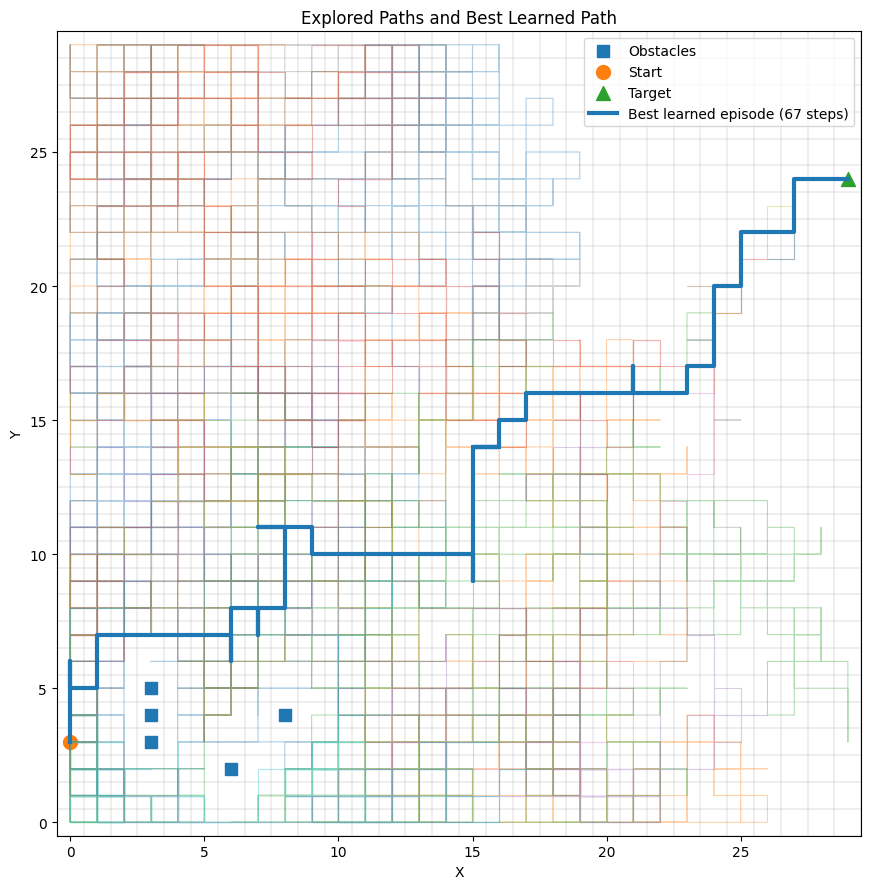

In [20]:
best_episode = int(np.argmin(robot_steps))
best_path = robot_paths[best_episode]

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_xlim(-0.5, GRID_W - 0.5)
ax.set_ylim(-0.5, GRID_H - 0.5)
ax.set_aspect("equal")

ax.set_xticks(np.arange(-0.5, GRID_W, 1), minor=True)
ax.set_yticks(np.arange(-0.5, GRID_H, 1), minor=True)
ax.grid(which="minor", linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

for ep in np.linspace(0, EPISODES_ROBOT - 1, 10, dtype=int):
    p = robot_paths[ep]
    ax.plot([x for x, y in p], [y for x, y in p], linewidth=0.8, alpha=0.35)

ax.scatter([p[0] for p in OBSTACLES], [p[1] for p in OBSTACLES],
           marker="s", s=70, label="Obstacles")
ax.scatter(*START, s=100, label="Start")
ax.scatter(*GOAL, s=100, marker="^", label="Target")

ax.plot(
    [x for x, y in best_path],
    [y for x, y in best_path],
    linewidth=3.0,
    label=f"Best learned episode ({robot_steps[best_episode]} steps)"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Explored Paths and Best Learned Path")
ax.legend()
plt.tight_layout()
plt.show()

## 37. Ground-Truth Shortest Path for Verification

The paper reports a shortest route of **50 steps**.

We can independently compute a shortest obstacle-avoiding path with breadth-first search (BFS). BFS is **not used to train Q-learning**; it is only a reference for checking the learned route.

Reference shortest-path moves: 50


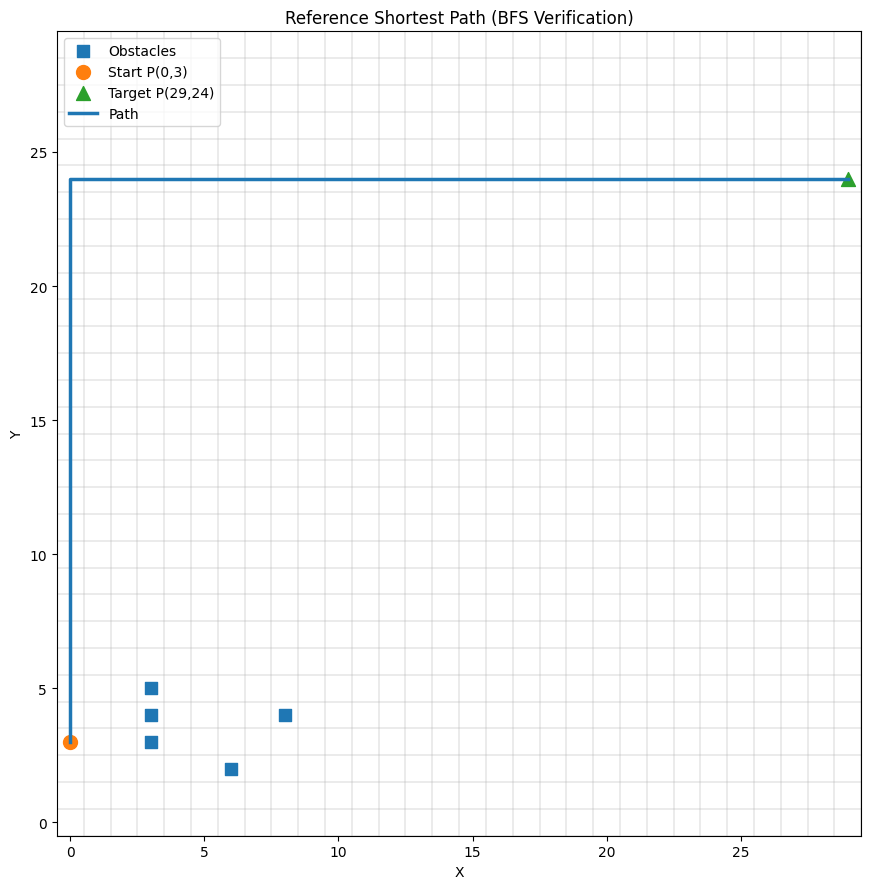

In [21]:
from collections import deque

def bfs_shortest_path(start, goal):
    queue = deque([start])
    parent = {start: None}

    while queue:
        current = queue.popleft()

        if current == goal:
            break

        for dx, dy in ACTION_DELTAS:
            nxt = (current[0] + dx, current[1] + dy)

            if (
                0 <= nxt[0] < GRID_W and
                0 <= nxt[1] < GRID_H and
                nxt not in OBSTACLES and
                nxt not in parent
            ):
                parent[nxt] = current
                queue.append(nxt)

    if goal not in parent:
        return None

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent[node]

    return path[::-1]

reference_path = bfs_shortest_path(START, GOAL)

print("Reference shortest-path moves:", len(reference_path) - 1)
draw_grid_map(reference_path, title="Reference Shortest Path (BFS Verification)")

## 38. Q-Values at Different States

The paper also visualizes learned Q-values across states.

For a compact portfolio plot, we show the maximum action value

$$
\max_a Q(s,a)
$$

for every grid cell.

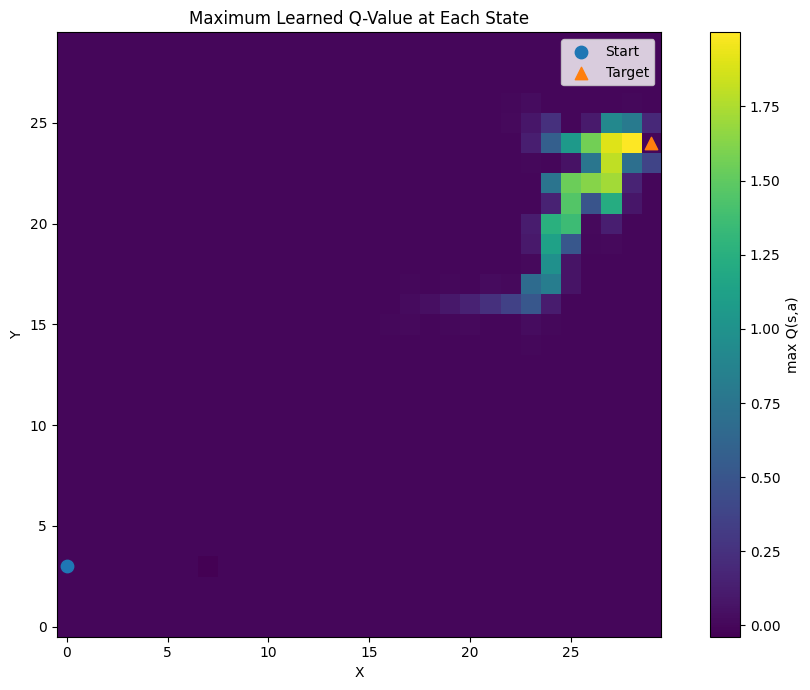

In [22]:
max_q_grid = np.max(q_robot, axis=1).reshape(GRID_H, GRID_W)

plt.figure(figsize=(10, 7))
plt.imshow(max_q_grid, origin="lower", aspect="equal")
plt.colorbar(label="max Q(s,a)")
plt.scatter(START[0], START[1], marker="o", s=80, label="Start")
plt.scatter(GOAL[0], GOAL[1], marker="^", s=80, label="Target")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Maximum Learned Q-Value at Each State")
plt.legend()
plt.tight_layout()
plt.show()

## 39. 3D Q-Values for State-Action Pairs

The paper includes a 3D view of state-action Q-values.

The following plot uses:

- x-axis: encoded state number;
- y-axis: action;
- z-axis: $Q(s,a)$.

/tmp/ipykernel_891/595063276.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


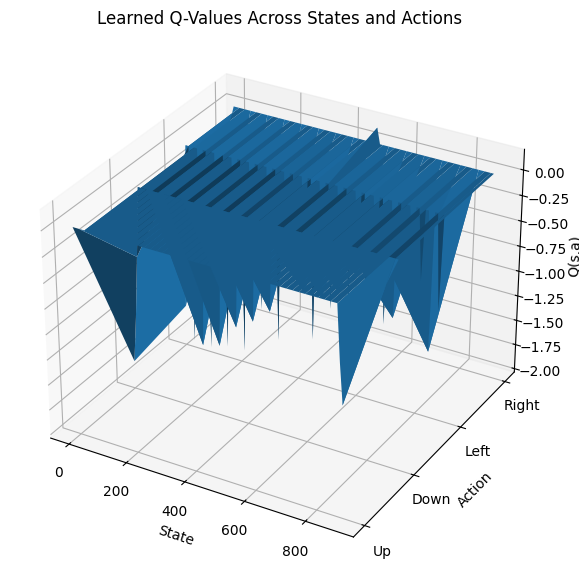

In [23]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

state_ids = np.arange(q_robot.shape[0])
sample_ids = state_ids[::10]

X, Y = np.meshgrid(sample_ids, np.arange(4))
Z = q_robot[sample_ids].T

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)
ax.set_xlabel("State")
ax.set_ylabel("Action")
ax.set_zlabel("Q(s,a)")
ax.set_yticks(range(4))
ax.set_yticklabels(ACTION_NAMES_ROBOT)
ax.set_title("Learned Q-Values Across States and Actions")
plt.tight_layout()
plt.show()

## 40. Q-Table Convergence

In addition to the paper-style steps-per-episode plot, we can directly monitor Q-table change:

$$
\Delta Q_e
=
\max_{s,a}
|Q_e(s,a)-Q_{e-1}(s,a)|.
$$

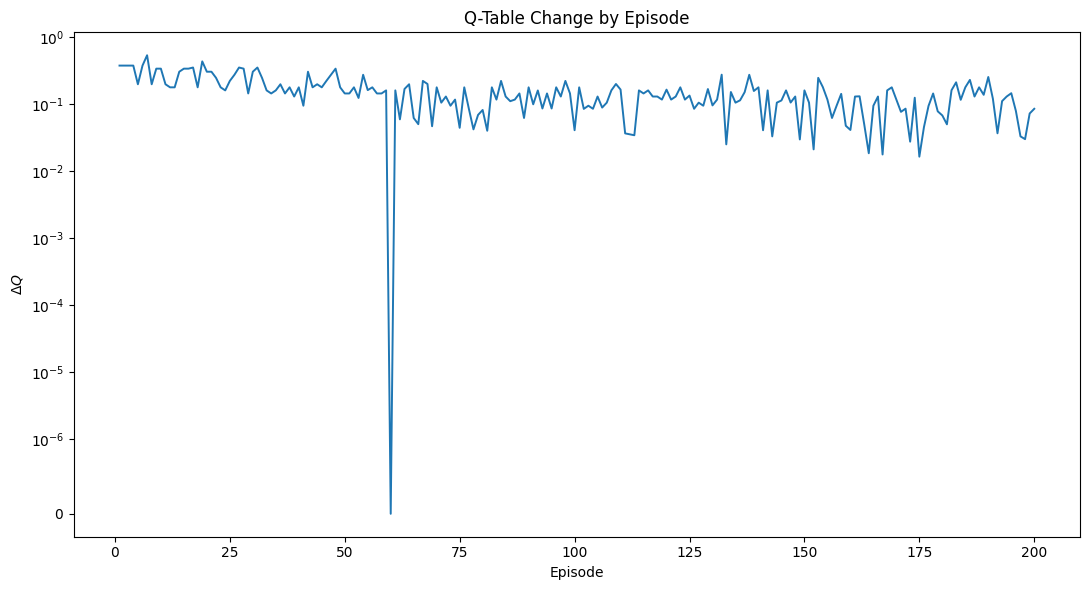

In [24]:
plt.figure(figsize=(11, 6))
plt.plot(np.arange(1, EPISODES_ROBOT + 1), robot_delta, linewidth=1.4)
plt.xlabel("Episode")
plt.ylabel(r"$\Delta Q$")
plt.title("Q-Table Change by Episode")
plt.yscale("symlog", linthresh=1e-6)
plt.tight_layout()
plt.show()

## 41. Real-Robot Experiment: $5\times9$ Corridor Map

For the real Voyager-IIA robot, the paper uses a smaller topological map:

$$
5\times9.
$$

The paper states:

$$
P_{\text{start}}=(0,0),
\qquad
P_{\text{target}}=(4,8).
$$

Each grid movement is treated as approximately $0.5$ m for navigation.

The obstacle positions below are a **schematic reconstruction from the slide**, not coordinates explicitly listed in the paper text.

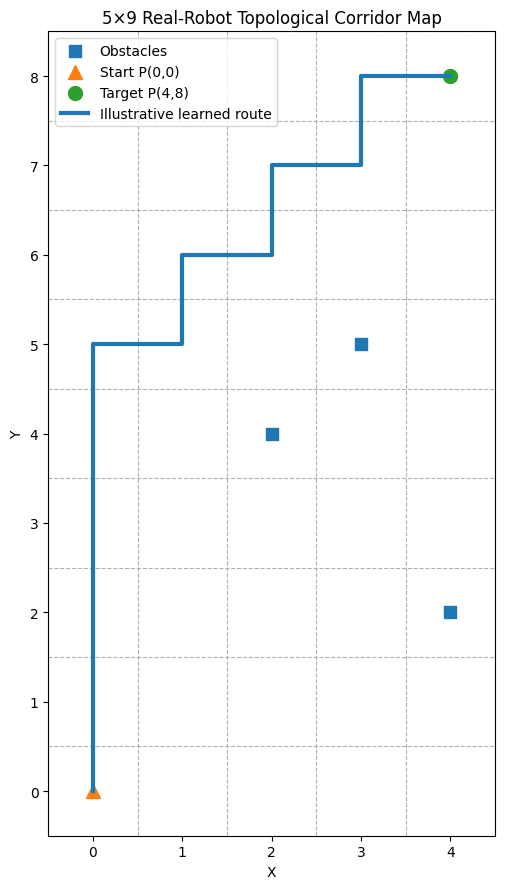

In [25]:
REAL_W = 5
REAL_H = 9
REAL_START = (0, 0)
REAL_GOAL = (4, 8)

# Schematic reconstruction from the slide's 5×9 topological map.
REAL_OBSTACLES = {(4, 2), (3, 5), (2, 4)}

fig, ax = plt.subplots(figsize=(6, 9))
ax.set_xlim(-0.5, REAL_W - 0.5)
ax.set_ylim(-0.5, REAL_H - 0.5)
ax.set_aspect("equal")

ax.set_xticks(np.arange(-0.5, REAL_W, 1), minor=True)
ax.set_yticks(np.arange(-0.5, REAL_H, 1), minor=True)
ax.grid(which="minor", linestyle="--", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

ax.scatter([p[0] for p in REAL_OBSTACLES],
           [p[1] for p in REAL_OBSTACLES],
           marker="s", s=80, label="Obstacles")
ax.scatter(*REAL_START, marker="^", s=100, label="Start P(0,0)")
ax.scatter(*REAL_GOAL, marker="o", s=100, label="Target P(4,8)")

# One schematic route similar to the stair-step route in the slide.
route = [(0,0),(0,1),(0,2),(0,3),(0,4),(0,5),
         (1,5),(1,6),(2,6),(2,7),(3,7),(3,8),(4,8)]
ax.plot([p[0] for p in route], [p[1] for p in route],
        linewidth=3, label="Illustrative learned route")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("5×9 Real-Robot Topological Corridor Map")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 42. Real Robot Workflow

The real robot does not simply execute one long open-loop command.

The workflow is:

1. initialize robot/environment/communication;
2. obtain the learned path;
3. determine the next motion direction;
4. issue forward/left/right/backward/stop command;
5. send the command to the robot;
6. move;
7. check whether the target has been reached;
8. repeat until completion.

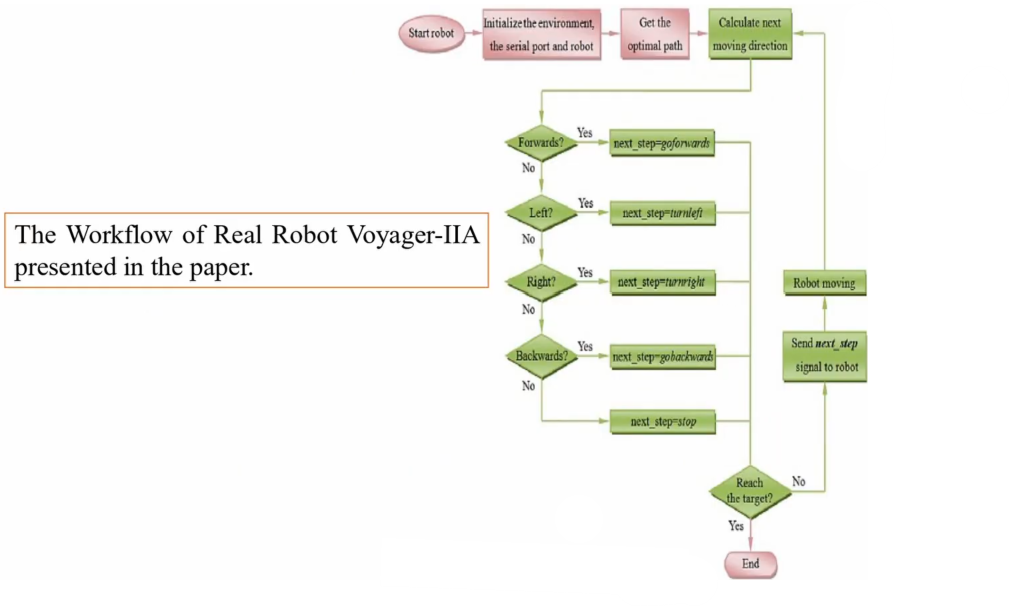